# 🧪 Fear & Greed Index Verification

This notebook verifies the implementation of the Fear & Greed Index indicator, specifically its ability to load and integrate external data (VIX, GOLD).

In [1]:
# Setup: Add project root to path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

# Imports
from user_data.indicators.fear_and_greed import fear_and_greed_index, load_external_dataframe
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# Test: Load External Data
vix = load_external_dataframe('VIX/USDT', '1d')
gold = load_external_dataframe('GOLD/USDT', '1d')

print("VIX Data loaded:", not vix.empty)
if not vix.empty:
    print("VIX sample:", vix.tail(3))
    
print("\nGOLD Data loaded:", not gold.empty)
if not gold.empty:
    print("GOLD sample:", gold.tail(3))

VIX Data loaded: True
VIX sample:                                 open       high    low  close  volume
date                                                                 
2026-01-21 05:00:00+00:00  19.309999  20.809999  16.67  16.90     0.0
2026-01-22 05:00:00+00:00  16.650000  16.670000  15.27  15.64     0.0
2026-01-23 05:00:00+00:00  15.680000  16.209999  15.62  15.68     0.0

GOLD Data loaded: True
GOLD sample:                                   open         high          low        close  \
date                                                                            
2026-01-21 05:00:00+00:00  4863.500000  4872.299805  4771.500000  4831.799805   
2026-01-22 05:00:00+00:00  4791.899902  4908.799805  4791.899902  4908.799805   
2026-01-23 05:00:00+00:00  4940.000000  4970.000000  4901.200195  4951.700195   

                             volume  
date                                 
2026-01-21 05:00:00+00:00    1706.0  
2026-01-22 05:00:00+00:00    1706.0  
2026-01-23 05:00:00+0

In [3]:
# Load Sample BTC Data
PAIR = "BTC_USDT_USDT"
TIMEFRAME = "4h"
LOOKBACK_CANDLES = 2160 # Adjustable lookback period

data_path = PROJECT_ROOT / "user_data" / "data" / "binance" / "futures" / f"{PAIR}-{TIMEFRAME}-futures.feather"

if data_path.exists():
    df = pd.read_feather(data_path)
    print(f"Loaded {len(df)} candles for {PAIR}")
    
    # Filter data to specified lookback period
    df = df.tail(LOOKBACK_CANDLES).copy()
    print(f"Analyzing last {len(df)} candles")
    
    df = df.set_index('date') # Indicator needs datetime index for reindexing external data
else:
    print("⚠️ Data file not found")


Loaded 2193 candles for BTC_USDT_USDT
Analyzing last 2160 candles


In [4]:
# Apply F&G Indicator
if 'df' in locals():
    df['fgi'] = fear_and_greed_index(df)
    print("Indicator added. FGI Range:", df['fgi'].min(), "to", df['fgi'].max())
    print("Tail:\n", df[['close', 'fgi']].tail())

Indicator added. FGI Range: -40.53697391181947 to 11.789455047201114
Tail:
                              close       fgi
date                                        
2026-01-22 16:00:00+00:00  89732.9 -0.873778
2026-01-22 20:00:00+00:00  89518.5 -0.579492
2026-01-23 00:00:00+00:00  89886.1 -0.302158
2026-01-23 04:00:00+00:00  89497.2 -0.148984
2026-01-23 08:00:00+00:00  89171.2 -0.040161


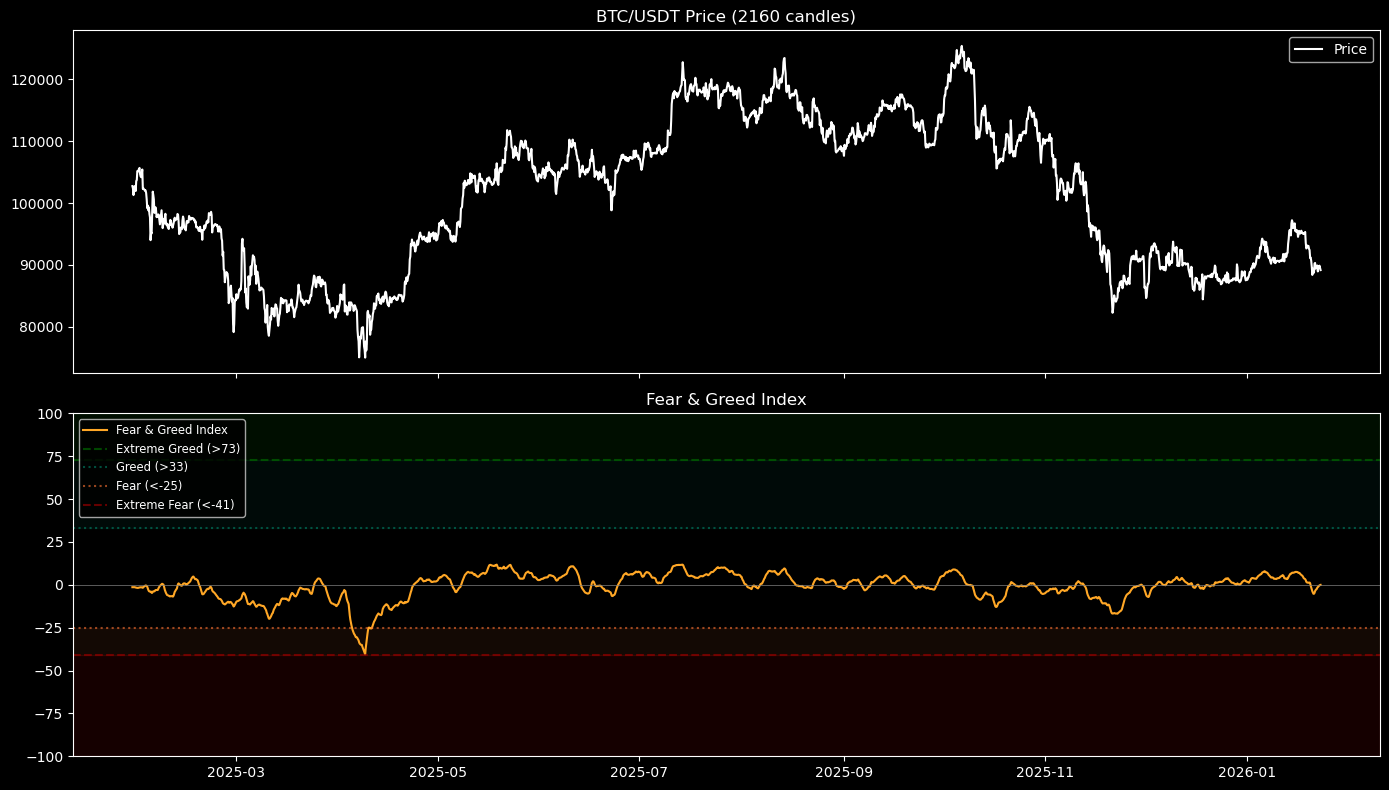

In [5]:
# Plotting
if 'df' in locals():
    # Use already filtered dataframe
    plot_df = df
    
    plt.style.use('dark_background')
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # 1. Price
    axes[0].plot(plot_df.index, plot_df['close'], label='Price', color='white')
    axes[0].set_title(f'BTC/USDT Price ({LOOKBACK_CANDLES} candles)')
    axes[0].legend()

    # 2. Fear & Greed
    axes[1].plot(plot_df.index, plot_df['fgi'], label='Fear & Greed Index', color='#FFA726', linewidth=1.5)
    
    # --- Levels & Zones (Matching Pine Script) ---
    # Extreme Greed (> 73)
    axes[1].axhline(73, color='#006400', linestyle='--', alpha=0.7, label='Extreme Greed (>73)')
    axes[1].axhspan(73, 100, color='#006400', alpha=0.15)

    # Greed (33 to 73)
    axes[1].axhline(33, color='#008368', linestyle=':', alpha=0.6, label='Greed (>33)')
    axes[1].axhspan(33, 73, color='#008368', alpha=0.08)
    
    # Neutral (-25 to 33) - Implicit middle zone
    axes[1].axhline(0, color='gray', linestyle='-', linewidth=0.5)
    
    # Fear (-25 to -41)
    axes[1].axhline(-25, color='#ff7434', linestyle=':', alpha=0.6, label='Fear (<-25)')
    axes[1].axhspan(-41, -25, color='#ff7434', alpha=0.08)

    # Extreme Fear (< -41)
    axes[1].axhline(-41, color='#910000', linestyle='--', alpha=0.7, label='Extreme Fear (<-41)')
    axes[1].axhspan(-100, -41, color='#910000', alpha=0.15)

    axes[1].set_title('Fear & Greed Index')
    axes[1].legend(loc='upper left', fontsize='small')
    axes[1].set_ylim(-100, 100) # Optional: Fix y-range if FGI stays within bounds

    plt.tight_layout()
    plt.show()